In [17]:
using CSV
using DataFrames
using DelimitedFiles
using CairoMakie
using LsqFit


In [2]:
messung_1_1 = readdlm("sensor1_1", '\t', Float64, skipstart = 2)
#=\t gibt an dass Julia da trennen soll wo die Spalten durch Tabulaor-Zeichen getrennt sind
ist nicht immer notwendig.
Da code im Seelber Ordner ist wie die Datei die ich will, brauche ich diesmal nichtt den 
Pfad, der name reicht.
=#

1506×2 Matrix{Float64}:
 2.01961e-5  0.0273931
 2.03131e-5  0.0273918
 2.02928e-5  0.0273909
 2.02153e-5  0.0273908
 2.02634e-5  0.0273915
 2.02193e-5  0.027392
 2.01249e-5  0.0273926
 2.00231e-5  0.0273923
 2.0026e-5   0.0273914
 1.99559e-5  0.0273915
 ⋮           
 2.16185e-5  0.0276951
 2.16473e-5  0.027692
 2.16575e-5  0.0276883
 2.1506e-5   0.0276875
 2.14641e-5  0.0276863
 2.14483e-5  0.0276844
 2.13352e-5  0.0276819
 2.13081e-5  0.0276806
 2.12782e-5  0.0276772

In [3]:
U = messung_1_1[:,2]
I = messung_1_1[:,1]


1506-element Vector{Float64}:
 2.01961266e-5
 2.03131476e-5
 2.02927968e-5
 2.02153478e-5
 2.02634001e-5
 2.02193041e-5
 2.01248949e-5
 2.00231389e-5
 2.00259656e-5
 1.99558654e-5
 ⋮
 2.16184744e-5
 2.16473054e-5
 2.16574808e-5
 2.15059754e-5
 2.14641423e-5
 2.14483116e-5
 2.13352487e-5
 2.1308113e-5
 2.12781506e-5

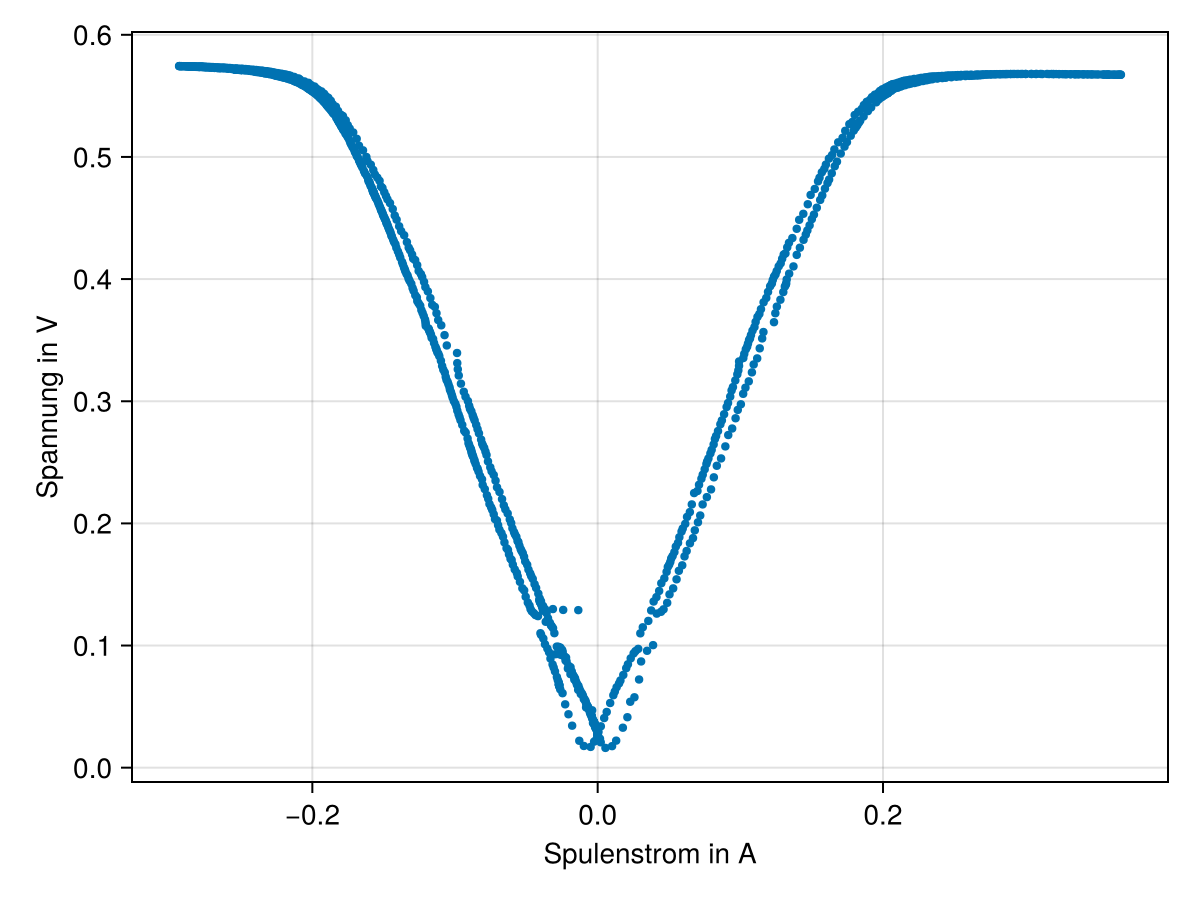

In [4]:
fig1 = Figure()
ax = Axis(fig1[1,1], xlabel = "Spulenstrom in A", ylabel = "Spannung in V")
scatter!(ax, I, U, markersize = 6)
fig1

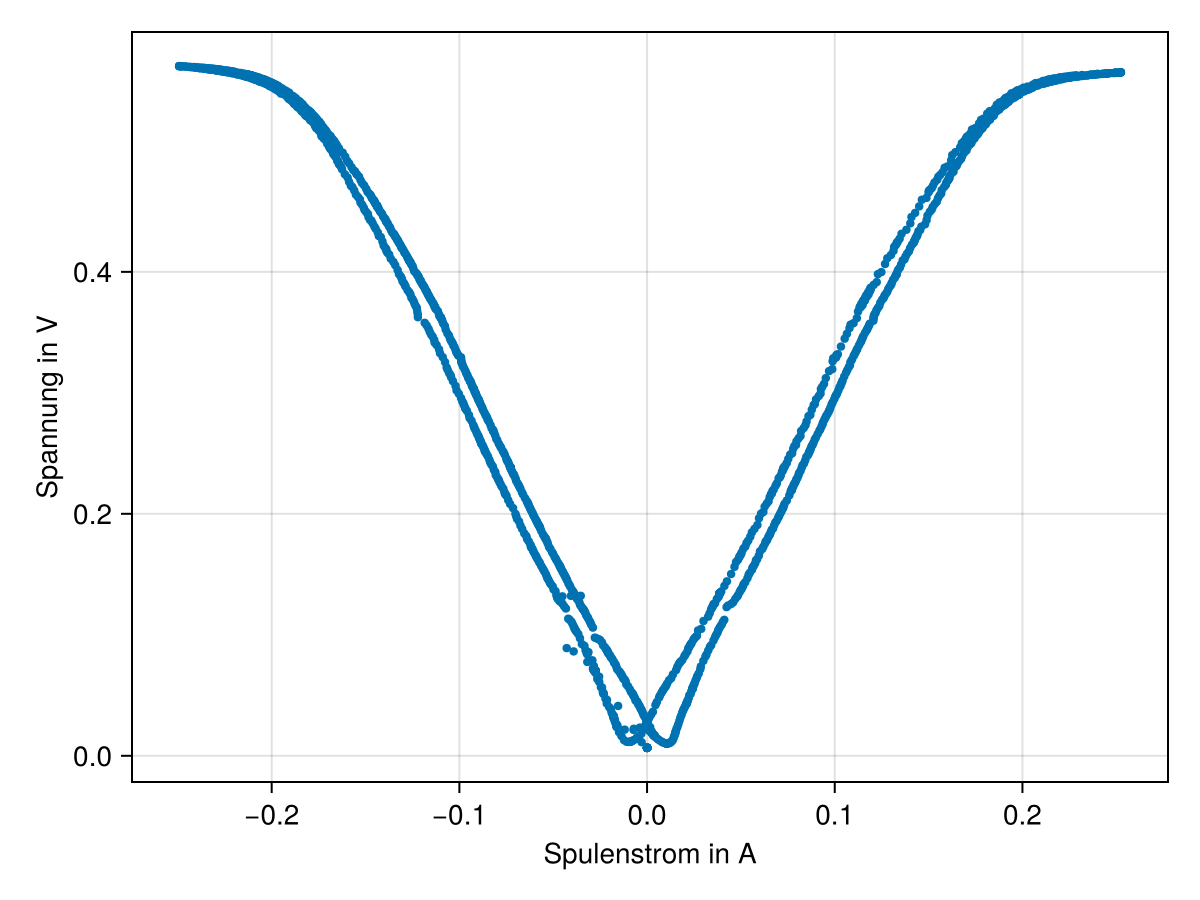

In [5]:
messung_1_2 = readdlm("sensor1_2", Float64, skipstart = 2)

I12 = messung_1_2[:,1] 
U12 = messung_1_2[:,2]

fig2=Figure()
ax = Axis(fig2[1,1], xlabel="Spulenstrom in A", ylabel="Spannung in V")
scatter!(ax, I12, U12, markersize=6)
fig2
#Ich nehme das Zweite, da hier weniger geruckel auf den geraden ist




In [ ]:
save("Spannung_vs_Strom_1_2.pdf", fig2)

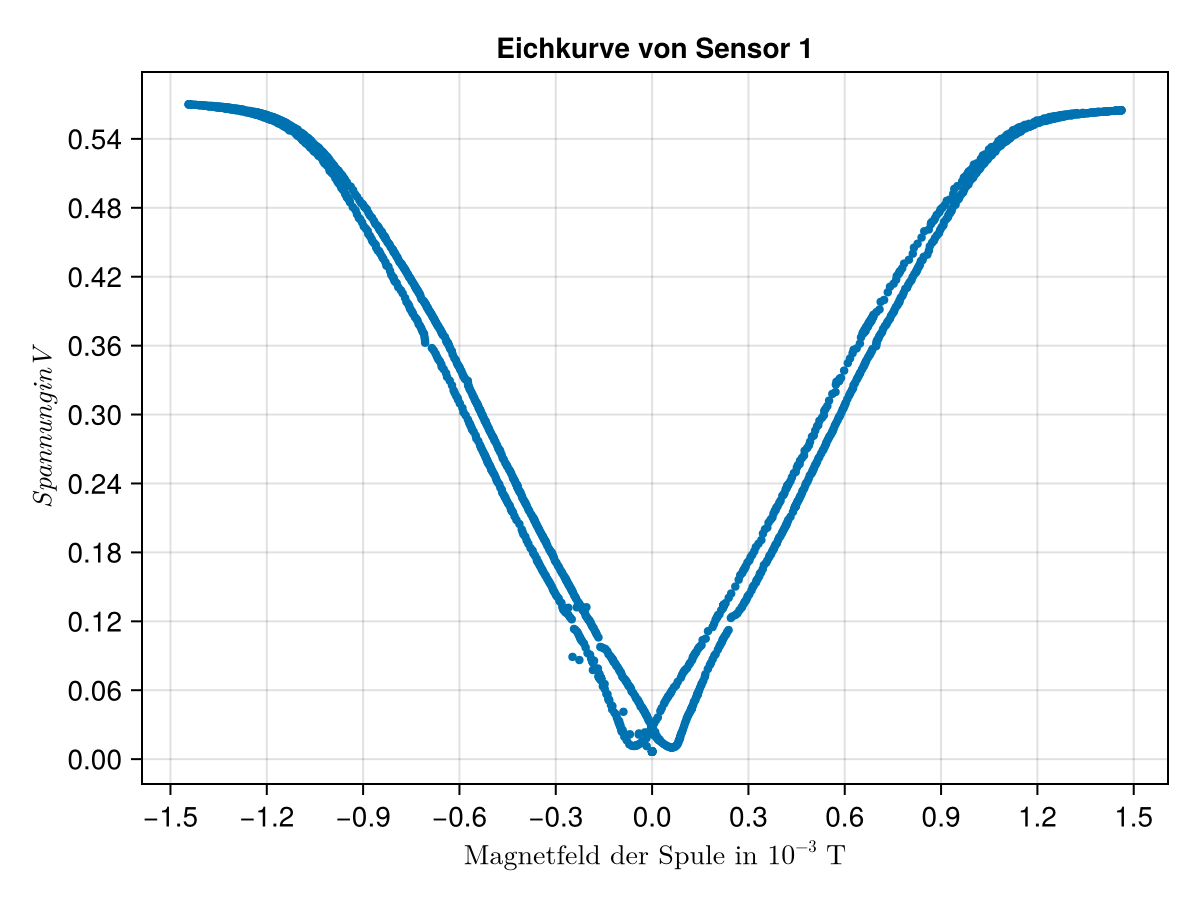

In [11]:
#B berechnen
N = 691
L = 0.15 # in m
μ0 = 4π*1e-7

B12 = I12 .* (μ0*N/L)
B12_skaliert = B12 ./ 1e-3 #Damit x-Achse nicht so voll, gröenordnung in beschritung

fig3 = Figure()
ax=Axis(fig3[1,1], xlabel= L"Magnetfeld der Spule in $10^{-3}$ T", ylabel=L"Spannung in V",
 title="Eichkurve von Sensor 1", xticks = LinearTicks(11), yticks = LinearTicks(11))
scatter!(ax, B12_skaliert, U12, markersize=6)
fig3

#L"..." aktiviert Latex

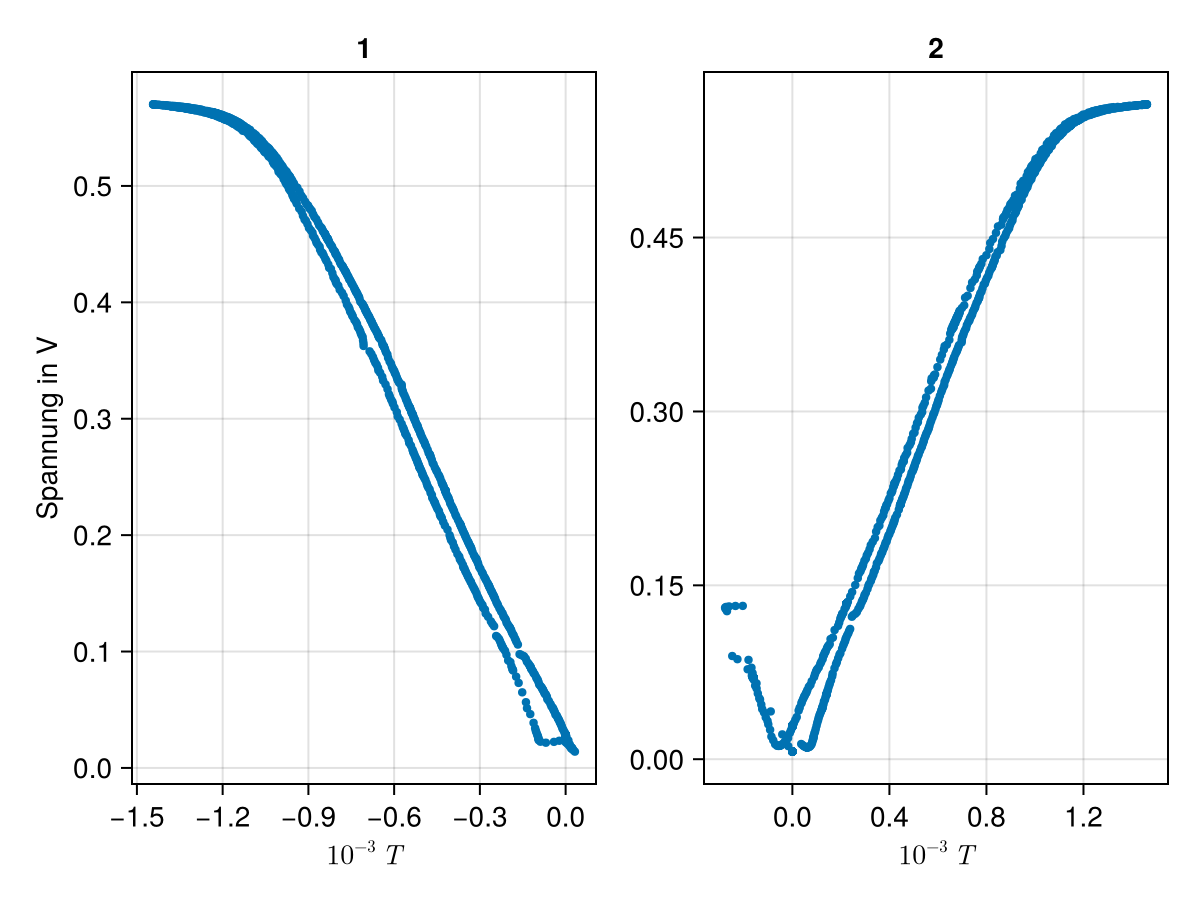

In [50]:
#Kurve in zwei Teile aufteilen mit pos und neg Steigung jeweils

länge = length(B12)
H = Int(länge /2)
#1. Hälfte, aufsteigend
U12_auf = U12[1:H]
B12_skaliert_auf = B12_skaliert[1:H]

#2.Hälft2, absteigend
U12_ab =U12[H+1:end]
B12_skaliert_ab = B12_skaliert[H+1:end]

fig5 = Figure()
ax1 = Axis(fig5[1,1], xlabel = L" 10^{-3}\:T", ylabel ="Spannung in V", title ="1",
xticks = LinearTicks(6), yticks = LinearTicks(7))
ax2 = Axis(fig5[1,2], xlabel = L" 10^{-3}\:T", title ="2", xticks = LinearTicks(6), 
yticks = LinearTicks(6))

CairoMakie.scatter!(ax1, B12_skaliert_auf, U12_auf, markersize=6)
CairoMakie.scatter!(ax2, B12_skaliert_ab, U12_ab, markersize=6)
fig5